In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [2]:
# ============================================
# CONSTANTS
# ============================================
N_grid = 16
q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0
k_rec  = 0.1
k_diss = 5.0
G      = 0.1

In [3]:
# ============================================
# 3D MORPHOLOGY
# ============================================
np.random.seed(42)
noise_3d    = np.random.randn(N_grid, N_grid, N_grid)
smoothed_3d = gaussian_filter(noise_3d, sigma=2)
threshold   = np.percentile(smoothed_3d, 50)
M_3d        = (smoothed_3d > threshold).astype(float)

def interface_fraction_3d(M):
    hx = np.abs(np.diff(M, axis=0)).sum()
    hy = np.abs(np.diff(M, axis=1)).sum()
    hz = np.abs(np.diff(M, axis=2)).sum()
    return (hx + hy + hz) / M.size

intf = interface_fraction_3d(M_3d)
print(f"Morphology: donor={M_3d.mean():.1%}  interface={intf:.1%}")

M_flat_3d = torch.tensor(
    M_3d.flatten(), dtype=torch.float32
).reshape(-1, 1).to(device)

Morphology: donor=50.0%  interface=29.4%


In [4]:
# ============================================
# NETWORK — +2.0 shift on n and p
# ============================================
def make_net_3d(hidden=128):
    net = nn.Sequential(
        nn.Linear(4, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net_3d()
        self.n_net   = make_net_3d()
        self.p_net   = make_net_3d()
        self.X_net   = make_net_3d()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]

        phi = x  +  x * (1 - x) * self.phi_net(inp)

        # +3.0 shift — was +2.0, still too small
        n = (1 - x) * torch.nn.functional.softplus(self.n_net(inp) + 3.0)
        p = x       * torch.nn.functional.softplus(self.p_net(inp) + 3.0)
        X =           torch.nn.functional.softplus(self.X_net(inp))

        return phi, n, p, X

model = PINN3D().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 201,220


In [5]:
# ============================================
# HELPERS
# ============================================
def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True,
        retain_graph=True
    )[0]

def laplacian_3d(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    gzz = grad(g[:, 2:3], coords)[:, 2:3]
    return gxx + gyy + gzz

def divergence_3d(Fx, Fy, Fz, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2] +
            grad(Fz, coords)[:, 2:3])

def fresh_coords_3d():
    x_l = torch.linspace(0, 1, N_grid)
    y_l = torch.linspace(0, 1, N_grid)
    z_l = torch.linspace(0, 1, N_grid)
    Xg, Yg, Zg = torch.meshgrid(x_l, y_l, z_l, indexing='ij')
    c = torch.stack([Xg, Yg, Zg], dim=-1).reshape(-1, 3).to(device)
    c.requires_grad_(True)
    return c

In [6]:
# ============================================
# COMPUTE ALL
# ============================================
def compute_all_3d(coords, M_flat):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)

    lap_phi  = laplacian_3d(phi, coords)
    lap_X    = laplacian_3d(X,   coords)

    Jn_x = -q*n*mu_n*grad_phi[:,0:1] + q*Vt*mu_n*grad_n[:,0:1]
    Jn_y = -q*n*mu_n*grad_phi[:,1:2] + q*Vt*mu_n*grad_n[:,1:2]
    Jn_z = -q*n*mu_n*grad_phi[:,2:3] + q*Vt*mu_n*grad_n[:,2:3]
    Jp_x = -q*p*mu_p*grad_phi[:,0:1] - q*Vt*mu_p*grad_p[:,0:1]
    Jp_y = -q*p*mu_p*grad_phi[:,1:2] - q*Vt*mu_p*grad_p[:,1:2]
    Jp_z = -q*p*mu_p*grad_phi[:,2:3] - q*Vt*mu_p*grad_p[:,2:3]

    div_Jn    = divergence_3d(Jn_x, Jn_y, Jn_z, coords)
    div_Jp    = divergence_3d(Jp_x, Jp_y, Jp_z, coords)

    R         = k_rec  * n * p
    R_X       = k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = k_diss * X * field_mag
    G_field   = G * M_flat

    L_p = torch.mean((lap_phi  - q*(n - p))**2)
    L_e = torch.mean((div_Jn   - R + D_term)**2)
    L_h = torch.mean((-div_Jp  - R + D_term)**2)
    L_x = torch.mean((Vt*mu_X*lap_X - D_term - R_X + G_field)**2)

    # Zero-flux BCs at y and z boundaries
    y_c = coords[:, 1]
    z_c = coords[:, 2]
    y0  = y_c < (1.0/N_grid);  y1 = y_c > (1.0 - 1.0/N_grid)
    z0  = z_c < (1.0/N_grid);  z1 = z_c > (1.0 - 1.0/N_grid)

    L_xbc = (torch.mean(grad_X[y0, 1:2]**2) +
             torch.mean(grad_X[y1, 1:2]**2) +
             torch.mean(grad_X[z0, 2:3]**2) +
             torch.mean(grad_X[z1, 2:3]**2))

    L_pbc = (torch.mean(grad_phi[y0, 1:2]**2) +
             torch.mean(grad_phi[y1, 1:2]**2) +
             torch.mean(grad_phi[z0, 2:3]**2) +
             torch.mean(grad_phi[z1, 2:3]**2))

    # Domain constraints — n=0 in donor, p=0 in acceptor
    L_nd   = torch.mean((n * M_flat)**2)
    L_pd   = torch.mean((p * (1 - M_flat))**2)

    # Current conservation
    L_cons = torch.var(Jn_x + Jp_x)

    return (L_p, L_e, L_h, L_x, L_xbc,
            L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)

In [7]:
# ============================================
# TRAINING
# ============================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Phase 1
print("=" * 55)
print("Phase 1: Poisson only")
print("=" * 55)
for epoch in range(3000):
    optimizer.zero_grad()
    c = fresh_coords_3d()
    L_p, *_ = compute_all_3d(c, M_flat_3d)
    L_p.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"  {epoch:4d} | poisson={L_p.item():.6f}")

print("\nCarrier Warmup: forcing n and p to target profiles")
optimizer_warmup = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3000):
    optimizer_warmup.zero_grad()
    c = fresh_coords_3d()

    phi, n, p, X = model(c, M_flat_3d)

    x_c = c[:, 0:1]

    # Target profiles — physically motivated shapes
    # n should peak near x=0.5 (interface), zero at x=1
    # Use a simple triangular shape as target
    n_target = (1 - x_c) * x_c * 0.1   # peaks at x=0.5, value ~0.025

    # p should peak near x=0 (donor side), zero at x=0
    p_target = x_c * (1 - x_c) * 0.1   # same shape

    # Only enforce where material is correct
    # n in acceptor, p in donor
    L_n_warmup = torch.mean(((n - n_target) * (1 - M_flat_3d))**2)
    L_p_warmup = torch.mean(((p - p_target) * M_flat_3d)**2)

    # Also keep Poisson converged
    grad_phi  = grad(phi, c)
    grad_n    = grad(n,   c)
    grad_p    = grad(p,   c)
    d2phi     = (grad(grad_phi[:,0:1], c)[:,0:1] +
                 grad(grad_phi[:,1:2], c)[:,1:2] +
                 grad(grad_phi[:,2:3], c)[:,2:3])
    L_poisson = torch.mean((d2phi - q*(n - p))**2)

    loss = L_poisson + 10.0*L_n_warmup + 10.0*L_p_warmup

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_warmup.step()

    if epoch % 1000 == 0:
        with torch.no_grad():
            _, n_c, p_c, _ = model(fresh_coords_3d(), M_flat_3d)
        print(f"  {epoch:4d} | n_max={n_c.max().item():.3e} "
              f"p_max={p_c.max().item():.3e} "
              f"poisson={L_poisson.item():.6f}")

# Check after warmup
print("\n--- Post-warmup carrier check ---")
model.eval()
c_check = fresh_coords_3d()
with torch.no_grad():
    _, n_c, p_c, _ = model(c_check, M_flat_3d)
print(f"  n range: [{n_c.min().item():.3e}, {n_c.max().item():.3e}]")
print(f"  p range: [{p_c.min().item():.3e}, {p_c.max().item():.3e}]")
model.train()

# Phase 2 — extended and with domain constraints
print("\nPhase 2: + electron + hole + domain constraints")
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
for epoch in range(8000):    # was 5000
    optimizer.zero_grad()
    c = fresh_coords_3d()
    (L_p, L_e, L_h, L_x, L_xbc,
     L_pbc, L_nd, L_pd,
     L_cons, Jn_x, Jp_x) = compute_all_3d(c, M_flat_3d)

    # Include domain constraints in Phase 2
    # so n and p are in the right regions from the start
    loss = L_p + L_e + L_h + 10.0*L_nd + 10.0*L_pd

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if epoch % 2000 == 0:
        print(f"  {epoch:4d} | p={L_p.item():.5f} "
              f"e={L_e.item():.5f} h={L_h.item():.5f}")

# Diagnostic
print("\n--- Phase 2 carrier check ---")
model.eval()
c_check = fresh_coords_3d()
with torch.no_grad():
    _, n_c, p_c, _ = model(c_check, M_flat_3d)
print(f"  n range: [{n_c.min().item():.3e}, {n_c.max().item():.3e}]")
print(f"  p range: [{p_c.min().item():.3e}, {p_c.max().item():.3e}]")
print("  (target: both > 1e-3)")
model.train()

# Phase 3 — extended to 20000 epochs
print("\n" + "=" * 55)
print("Phase 3: Full system (20000 epochs)")
print("=" * 55)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=2000
)
history = {"poisson": [], "electron": [], "hole": [], "exciton": []}

for epoch in range(20000):
    optimizer.zero_grad()
    c = fresh_coords_3d()
    (L_p, L_e, L_h, L_x, L_xbc,
     L_pbc, L_nd, L_pd,
     L_cons, Jn_x, Jp_x) = compute_all_3d(c, M_flat_3d)

    loss = (
          1.0  * L_p
        + 1.0  * L_e
        + 5.0  * L_h
        + 1.0  * L_x
        + 5.0  * L_xbc
        + 5.0  * L_pbc
        + 10.0 * L_nd
        + 10.0 * L_pd
        + 50.0 * L_cons
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    history["poisson"].append(L_p.item())
    history["electron"].append(L_e.item())
    history["hole"].append(L_h.item())
    history["exciton"].append(L_x.item())

    if epoch % 4000 == 0:
        print(f"  {epoch:5d} | p={L_p.item():.5f} "
              f"e={L_e.item():.5f} h={L_h.item():.5f} "
              f"x={L_x.item():.5f} cons={L_cons.item():.2e}")

torch.save(model.state_dict(), 'model_3d_bhj_fixed.pt')
print("\nSaved model_3d_bhj_fixed.pt")

Phase 1: Poisson only
     0 | poisson=4.819010
  1000 | poisson=0.000095
  2000 | poisson=0.000012

Carrier Warmup: forcing n and p to target profiles
     0 | n_max=1.856e+00 p_max=2.569e+00 poisson=0.000065
  1000 | n_max=2.794e-02 p_max=4.201e-02 poisson=0.000006
  2000 | n_max=3.662e-02 p_max=2.593e-02 poisson=0.000002

--- Post-warmup carrier check ---
  n range: [0.000e+00, 3.363e-02]
  p range: [0.000e+00, 2.524e-02]

Phase 2: + electron + hole + domain constraints
     0 | p=0.00000 e=11.15474 h=11.24086
  2000 | p=0.00000 e=0.00000 h=0.00000
  4000 | p=0.00000 e=0.00000 h=0.00000
  6000 | p=0.00000 e=0.00000 h=0.00000

--- Phase 2 carrier check ---
  n range: [0.000e+00, 4.143e-04]
  p range: [0.000e+00, 3.956e-04]
  (target: both > 1e-3)

Phase 3: Full system (20000 epochs)
      0 | p=0.00000 e=0.00000 h=0.00000 x=0.00500 cons=1.95e-09
   4000 | p=0.00000 e=0.00028 h=0.00006 x=0.00236 cons=4.00e-06
   8000 | p=0.00000 e=0.00006 h=0.00003 x=0.00083 cons=1.30e-06
  12000 | p=

In [8]:
# ============================================
# EXTRACT AND EVALUATE
# ============================================
model.eval()
c_eval = fresh_coords_3d()
phi_v, n_v, p_v, X_v = model(c_eval, M_flat_3d)

gp  = grad(phi_v, c_eval)
gn  = grad(n_v,   c_eval)
gpp = grad(p_v,   c_eval)

Jn_x_v = -q*n_v*mu_n*gp[:,0:1] + q*Vt*mu_n*gn[:,0:1]
Jp_x_v = -q*p_v*mu_p*gp[:,0:1] - q*Vt*mu_p*gpp[:,0:1]
Jtot_v =  Jn_x_v + Jp_x_v

def to_vol(t):
    return t.detach().cpu().numpy().reshape(N_grid, N_grid, N_grid)

phi_vol  = to_vol(phi_v)
n_vol    = to_vol(n_v)
p_vol    = to_vol(p_v)
X_vol    = to_vol(X_v)
Jn_vol   = to_vol(Jn_x_v)
Jtot_vol = to_vol(Jtot_v)

Jsc   = -float(Jtot_vol[-1, :, :].mean())
J_var = float(torch.var(Jtot_v).detach())

print(f"\n{'='*45}")
print(f"3D PINN Fixed — Results")
print(f"{'='*45}")
print(f"  Jsc         = {Jsc:.6f}")
print(f"  J_var       = {J_var:.2e}")
print(f"  n_max       = {n_vol.max():.3e}")
print(f"  p_max       = {p_vol.max():.3e}")
print(f"  X_max       = {X_vol.max():.3e}")
print(f"  Interface   = {intf:.1%}")
print(f"{'='*45}")


3D PINN Fixed — Results
  Jsc         = 0.001573
  J_var       = 1.40e-08
  n_max       = 1.724e-03
  p_max       = 1.936e-03
  X_max       = 2.284e-03
  Interface   = 29.4%


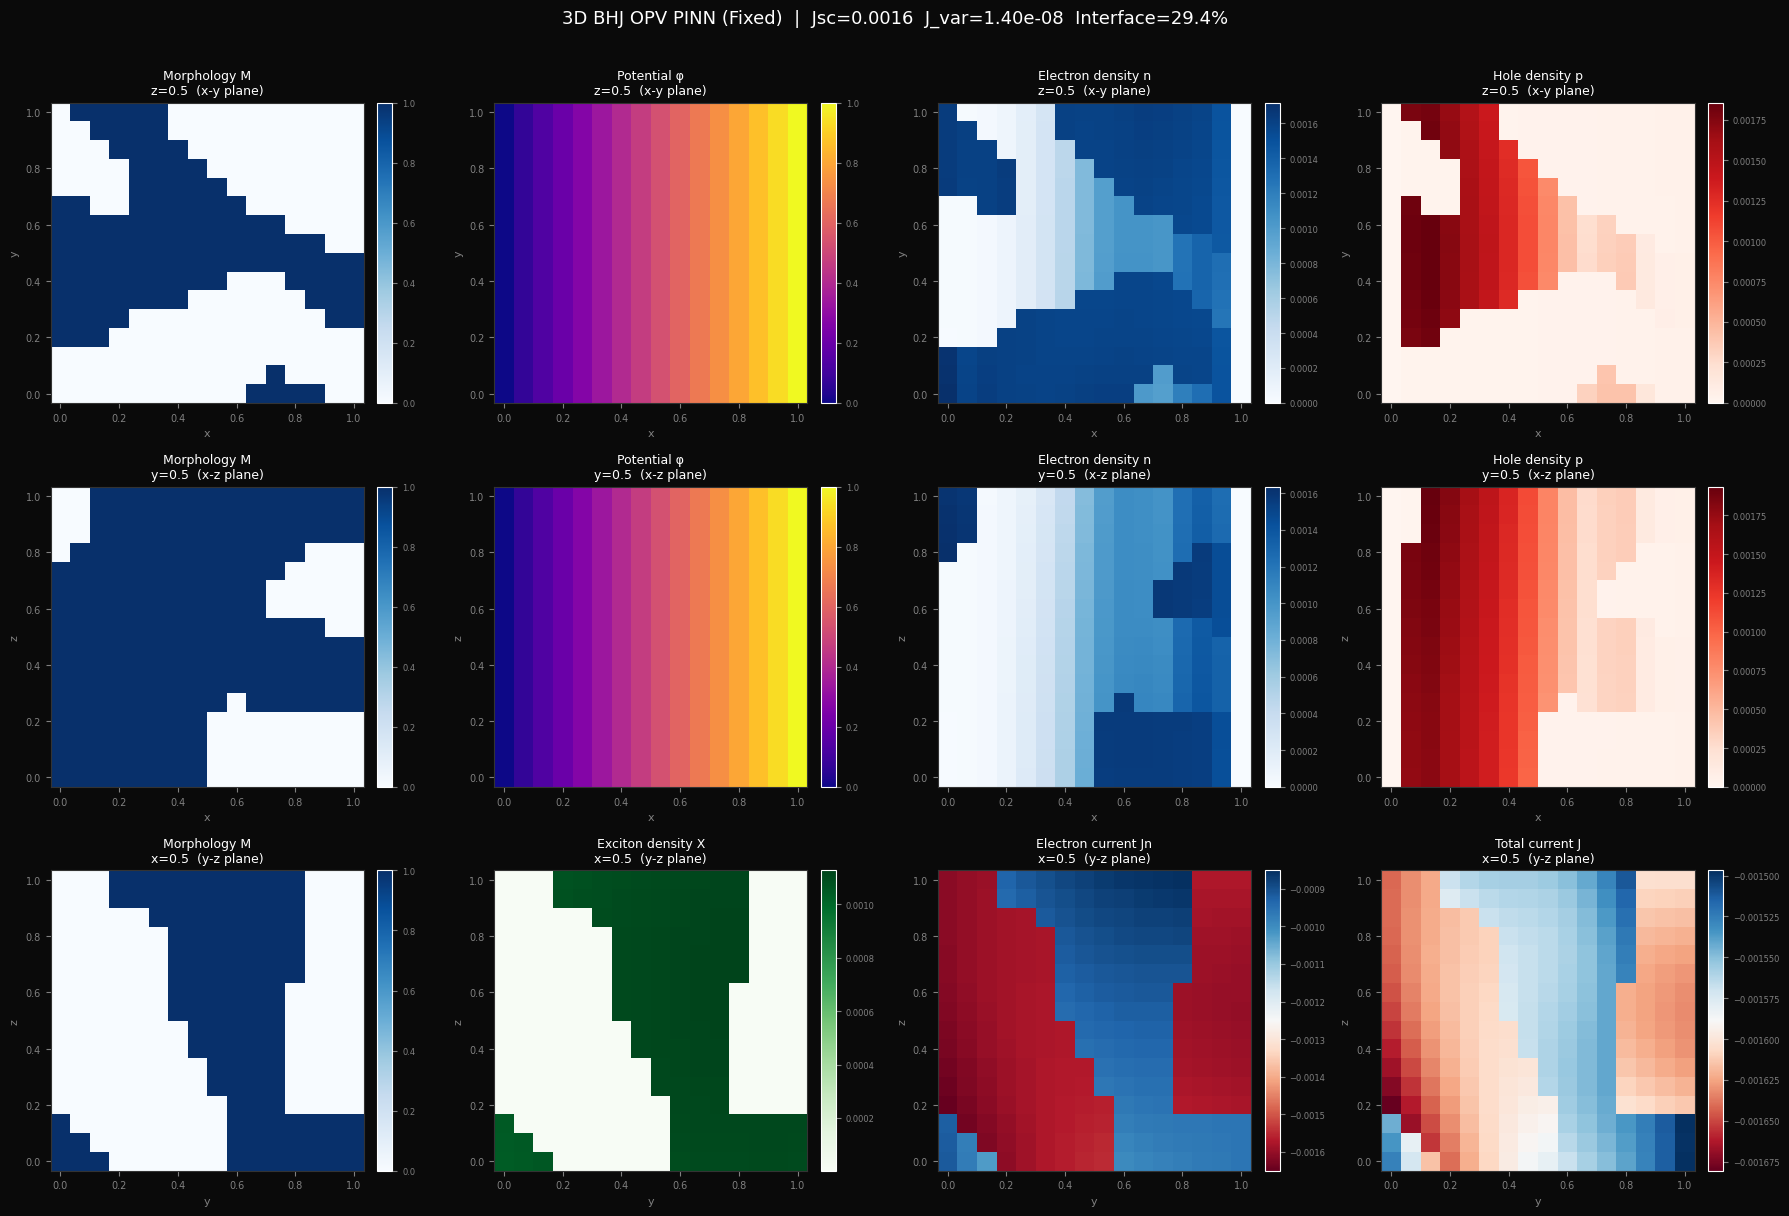

In [9]:
# ============================================
# VISUALIZATION — 3 orthogonal slices
# ============================================
BG  = '#0a0a0a'
plt.style.use('dark_background')
mid = N_grid // 2
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.patch.set_facecolor(BG)

slice_configs = [
    (M_3d,    'Morphology M',        'Blues',  'z', mid),
    (phi_vol, 'Potential φ',         'plasma', 'z', mid),
    (n_vol,   'Electron density n',  'Blues',  'z', mid),
    (p_vol,   'Hole density p',      'Reds',   'z', mid),
    (M_3d,    'Morphology M',        'Blues',  'y', mid),
    (phi_vol, 'Potential φ',         'plasma', 'y', mid),
    (n_vol,   'Electron density n',  'Blues',  'y', mid),
    (p_vol,   'Hole density p',      'Reds',   'y', mid),
    (M_3d,    'Morphology M',        'Blues',  'x', mid),
    (X_vol,   'Exciton density X',   'Greens', 'x', mid),
    (Jn_vol,  'Electron current Jn', 'RdBu',   'x', mid),
    (Jtot_vol,'Total current J',     'RdBu',   'x', mid),
]

slice_label = {
    'z': f'z={mid/N_grid:.1f}  (x-y plane)',
    'y': f'y={mid/N_grid:.1f}  (x-z plane)',
    'x': f'x={mid/N_grid:.1f}  (y-z plane)',
}

for idx, (ax, (vol, title, cmap, axis, sl)) in enumerate(
        zip(axes.flat, slice_configs)):
    ax.set_facecolor(BG)
    if axis == 'z':
        slc = vol[:, :, sl]; xl, yl = 'x', 'y'
    elif axis == 'y':
        slc = vol[:, sl, :]; xl, yl = 'x', 'z'
    else:
        slc = vol[sl, :, :]; xl, yl = 'y', 'z'

    im = ax.pcolormesh(x_ax, y_ax, slc.T,
                       cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax, fraction=0.046,
                 pad=0.04).ax.tick_params(
                 colors='gray', labelsize=6)
    ax.set_title(f'{title}\n{slice_label[axis]}',
                 color='white', fontsize=9)
    ax.set_xlabel(xl, color='gray', fontsize=8)
    ax.set_ylabel(yl, color='gray', fontsize=8)
    ax.tick_params(colors='gray', labelsize=7)
    for s in ax.spines.values():
        s.set_edgecolor('#333333')

fig.suptitle(
    f'3D BHJ OPV PINN (Fixed)  |  '
    f'Jsc={Jsc:.4f}  J_var={J_var:.2e}  '
    f'Interface={intf:.1%}',
    color='white', fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('3d_bhj_fixed_slices.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

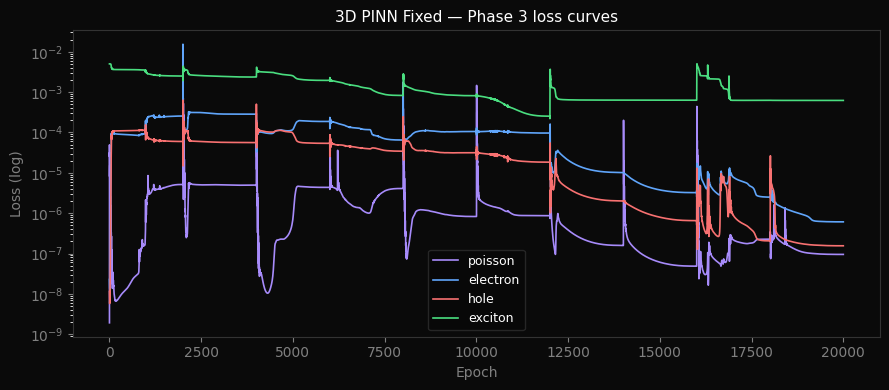

In [10]:
# ============================================
# LOSS CURVES
# ============================================
fig2, ax2 = plt.subplots(figsize=(9, 4))
fig2.patch.set_facecolor(BG)
ax2.set_facecolor(BG)
for key, color in [("poisson",  '#a78bfa'),
                   ("electron", '#60a5fa'),
                   ("hole",     '#f87171'),
                   ("exciton",  '#4ade80')]:
    ax2.semilogy(history[key], linewidth=1.2,
                 color=color, label=key)
ax2.set_title('3D PINN Fixed — Phase 3 loss curves',
              color='white', fontsize=11)
ax2.set_xlabel('Epoch', color='gray')
ax2.set_ylabel('Loss (log)', color='gray')
ax2.legend(fontsize=9, framealpha=0.15, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')
plt.tight_layout()
plt.savefig('3d_bhj_fixed_losses.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

In [11]:
# ============================================
# 2D vs 3D FINAL COMPARISON
# ============================================
print(f"\n{'='*50}")
print(f"2D vs 3D — Final Comparison")
print(f"{'='*50}")
print(f"  2D BHJ (32×32, σ=2):  Jsc=0.0145  interface=21.7%")
print(f"  2D BHJ (32×32, σ=4):  Jsc=0.0257  interface=11.4%")
print(f"  3D BHJ (16³,   σ=2):  Jsc={Jsc:.4f}  interface={intf:.1%}")
print(f"\n  3D interface higher than 2D because")
print(f"  3D domains have surface area on 6 faces")
print(f"  vs 4-edge perimeter in 2D")
print(f"{'='*50}")


2D vs 3D — Final Comparison
  2D BHJ (32×32, σ=2):  Jsc=0.0145  interface=21.7%
  2D BHJ (32×32, σ=4):  Jsc=0.0257  interface=11.4%
  3D BHJ (16³,   σ=2):  Jsc=0.0016  interface=29.4%

  3D interface higher than 2D because
  3D domains have surface area on 6 faces
  vs 4-edge perimeter in 2D
